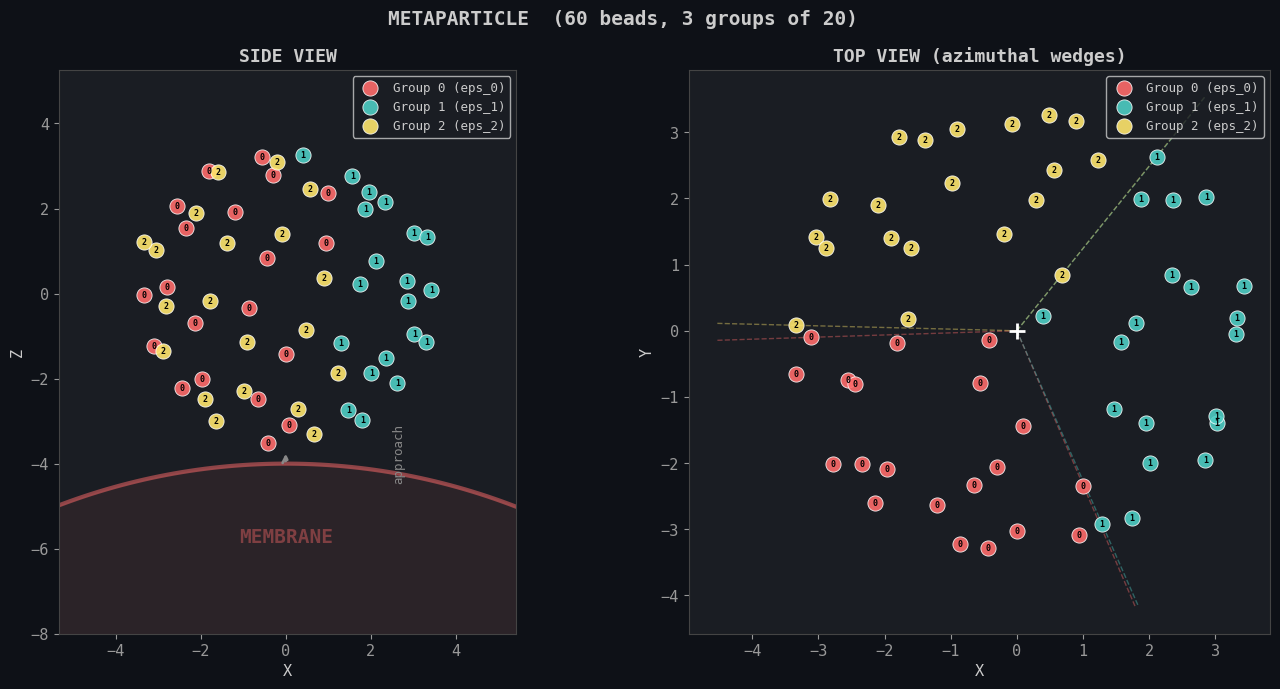

In [35]:
# METAPARTICLE: 3 azimuthal wedge groups colored
# Shows which group faces the membrane

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import griddata
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#1a1d23",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#ccc",
    "text.color": "#ccc",
    "xtick.color": "#999",
    "ytick.color": "#999",
    "grid.color": "#333",
    "grid.alpha": 0.4,
    "font.family": "monospace",
    "font.size": 11,
})

# Load bead group data
with open("bo_runs/bead_groups.json") as f:
    bg = json.load(f)

bead_info = bg["bead_info"]
coords = np.array([b["xyz"] for b in bead_info])
bead_groups = np.array([b["group"] for b in bead_info])

group_colors = ["#ff6b6b", "#4ecdc4", "#ffe66d"]
group_labels = ["Group 0 (eps_0)", "Group 1 (eps_1)", "Group 2 (eps_2)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# --- LEFT: Side view (XZ) with membrane below ---
theta_arc = np.linspace(-0.6, 0.6, 100)
mem_radius = 15
mem_center_z = -mem_radius - 4
arc_x = mem_radius * np.sin(theta_arc)
arc_z = mem_center_z + mem_radius * np.cos(theta_arc)
ax1.fill_between(arc_x, arc_z, arc_z.min() - 2, color="#ff6b6b", alpha=0.08)
ax1.plot(arc_x, arc_z, color="#ff6b6b", lw=3, alpha=0.5)
ax1.text(0, arc_z.max() - 1.5, "MEMBRANE", ha="center", va="top",
         fontsize=14, color="#ff6b6b", alpha=0.4, fontweight="bold")

ax1.annotate("", xy=(0, arc_z.max() + 0.3), xytext=(0, coords[:, 2].min() - 0.5),
             arrowprops=dict(arrowstyle="->", color="#888", lw=2, ls="--"))
ax1.text(2.5, (arc_z.max() + coords[:, 2].min()) / 2, "approach",
         fontsize=9, color="#888", rotation=90, ha="left", va="center")

for g in range(3):
    mask = bead_groups == g
    ax1.scatter(coords[mask, 0], coords[mask, 2], c=group_colors[g],
                s=120, edgecolors="white", linewidths=0.6, label=group_labels[g],
                alpha=0.9, zorder=5)

for b in bead_info:
    ax1.text(b["xyz"][0], b["xyz"][2], str(b["group"]),
             fontsize=6, ha="center", va="center", color="black",
             fontweight="bold", zorder=6)

ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.set_title("SIDE VIEW", fontweight="bold", fontsize=13)
ax1.set_aspect("equal")
ax1.legend(fontsize=9, loc="upper right")
pad = 2
ax1.set_xlim(coords[:, 0].min() - pad, coords[:, 0].max() + pad)
ax1.set_ylim(arc_z.max() - 4, coords[:, 2].max() + pad)

# --- RIGHT: Top-down view (XY) with wedge boundaries ---
for g in range(3):
    mask = bead_groups == g
    ax2.scatter(coords[mask, 0], coords[mask, 1], c=group_colors[g],
                s=120, edgecolors="white", linewidths=0.6, label=group_labels[g],
                alpha=0.9, zorder=5)

for b in bead_info:
    ax2.text(b["xyz"][0], b["xyz"][1], str(b["group"]),
             fontsize=6, ha="center", va="center", color="black",
             fontweight="bold", zorder=6)

r_max = np.max(np.linalg.norm(coords[:, :2], axis=1)) * 1.3
for g in range(3):
    g_thetas = sorted([b["theta_deg"] for b in bead_info if b["group"] == g])
    theta_min = np.radians(g_thetas[0])
    theta_max = np.radians(g_thetas[-1])
    ax2.plot([0, r_max * np.cos(theta_min)], [0, r_max * np.sin(theta_min)],
             color=group_colors[g], ls="--", lw=1, alpha=0.4)
    ax2.plot([0, r_max * np.cos(theta_max)], [0, r_max * np.sin(theta_max)],
             color=group_colors[g], ls="--", lw=1, alpha=0.4)

ax2.plot(0, 0, "+", color="white", ms=12, mew=2)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("TOP VIEW (azimuthal wedges)", fontweight="bold", fontsize=13)
ax2.set_aspect("equal")
ax2.legend(fontsize=9, loc="upper right")

fig.suptitle("METAPARTICLE  (60 beads, 3 groups of 20)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# Load BO results
results_path = Path("bo_runs/bo_results.json")
with open(results_path) as f:
    results = json.load(f)

ok = [r for r in results if r.get("status") == "success"]
eps = np.array([r["epsilons"] for r in ok])
scores = np.array([r["objective"] for r in ok])
rR = np.array([r["radial_ratio"] for r in ok])
eval_ids = np.array([r["eval_id"] for r in ok])
n_initial = 10  # Sobol phase size

print(f"{len(ok)}/{len(results)} runs  |  "
      f"inside: {(scores > 0.5).sum()}  |  "
      f"outside: {(scores <= 0.5).sum()}  |  "
      f"best r/R: {rR.min():.3f}")

9/9 runs  |  inside: 7  |  outside: 2  |  best r/R: 0.335


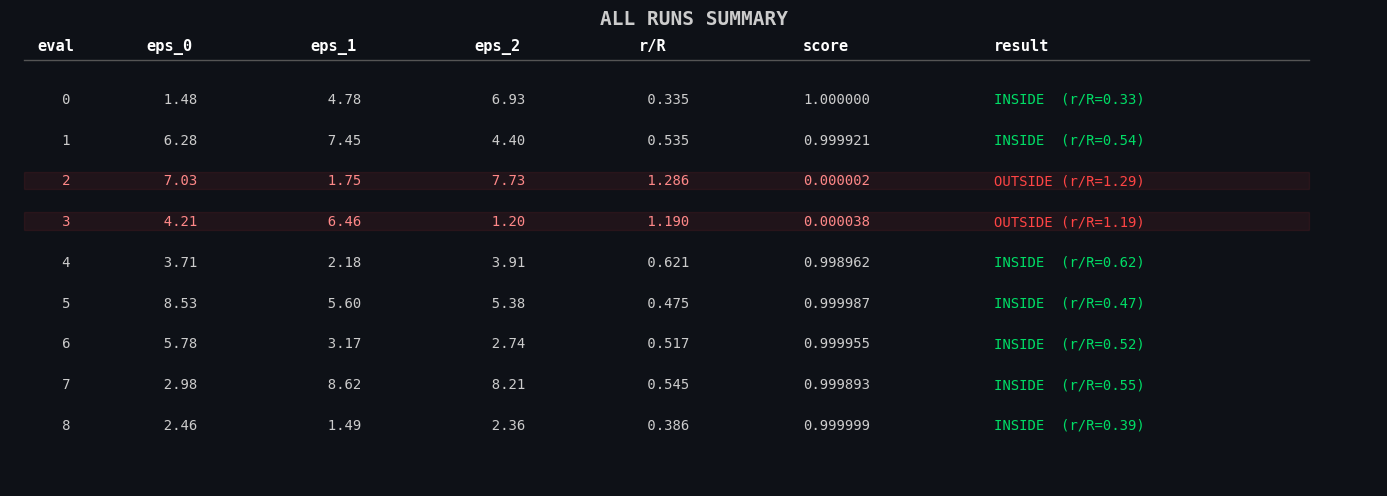

In [37]:
# SUMMARY TABLE: all runs at a glance
# Green = inside, red = failed (outside)

fig, ax = plt.subplots(figsize=(14, max(2, 0.4 * len(ok) + 1.5)))
ax.axis("off")

headers = ["eval", "eps_0", "eps_1", "eps_2", "r/R", "score", "result"]
col_x = [0.02, 0.10, 0.22, 0.34, 0.46, 0.58, 0.72]

# Header row
for x, h in zip(col_x, headers):
    ax.text(x, 1.0, h, fontsize=11, fontweight="bold", color="white",
            transform=ax.transAxes, va="top", family="monospace")
ax.plot([0.01, 0.95], [0.95, 0.95], color="#555", lw=1,
        transform=ax.transAxes, clip_on=False)

# Sort by eval_id
sorted_runs = sorted(ok, key=lambda r: r["eval_id"])
n = len(sorted_runs)

for i, r in enumerate(sorted_runs):
    y = 1.0 - (i + 1.5) / (n + 2)
    s = r["objective"]
    rr = r["radial_ratio"]
    e = r["epsilons"]

    # r/R < 1 means inside the membrane
    inside = rr < 1.0

    if inside:
        row_color = "#00dd66"
        result_text = f"INSIDE  (r/R={rr:.2f})"
    else:
        row_color = "#ff4444"
        result_text = f"OUTSIDE (r/R={rr:.2f})"

    vals = [
        f"{r['eval_id']:>4d}",
        f"{e[0]:>6.2f}",
        f"{e[1]:>6.2f}",
        f"{e[2]:>6.2f}",
        f"{rr:>6.3f}",
        f"{s:>8.6f}",
        result_text,
    ]

    for x, v in zip(col_x, vals):
        c = row_color if x == col_x[-1] else ("#ccc" if inside else "#ff8888")
        ax.text(x, y, v, fontsize=10, color=c,
                transform=ax.transAxes, va="center", family="monospace")

    # Highlight failures
    if not inside:
        rect = plt.Rectangle((0.01, y - 0.02), 0.94, 0.04,
                              transform=ax.transAxes, color="#ff4444",
                              alpha=0.08, clip_on=False)
        ax.add_patch(rect)

ax.set_title("ALL RUNS SUMMARY", fontweight="bold", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

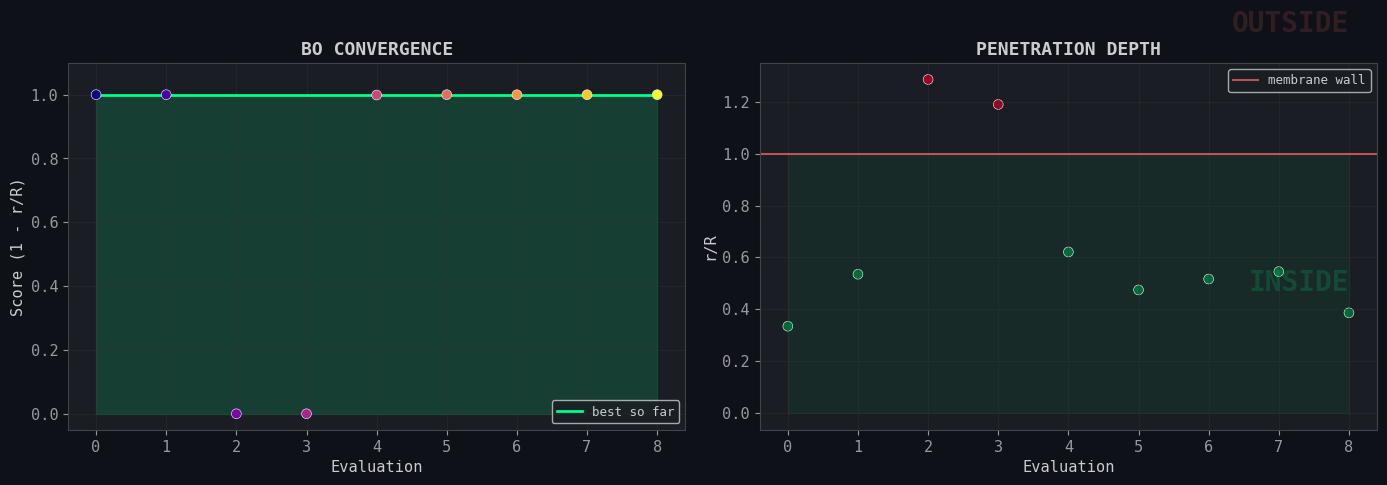

In [38]:
# 1. EXPLORATION TRAJECTORY
# How does BO move through epsilon space over time?
# Trail shows the path, color shifts from blue (early) to yellow (late)

fig = plt.figure(figsize=(14, 5))

# Left: cumulative best + individual scores with trail
ax1 = fig.add_subplot(121)
cum_best = np.maximum.accumulate(scores)

# Color by evaluation order
colors_time = plt.cm.plasma(np.linspace(0, 1, len(eval_ids)))
ax1.fill_between(eval_ids, 0, cum_best, alpha=0.15, color="#00ff88")
ax1.plot(eval_ids, cum_best, color="#00ff88", lw=2, label="best so far")
ax1.scatter(eval_ids, scores, c=np.arange(len(scores)), cmap="plasma",
            s=50, zorder=5, edgecolors="white", linewidths=0.4)

if len(eval_ids) > n_initial:
    ax1.axvline(n_initial - 0.5, color="#ff6b6b", ls="--", alpha=0.6)
    ax1.text(n_initial - 0.5, 1.02, "SOBOL | BO", ha="center",
             fontsize=8, color="#ff6b6b")

ax1.set_xlabel("Evaluation")
ax1.set_ylabel("Score (1 - r/R)")
ax1.set_title("BO CONVERGENCE", fontweight="bold", fontsize=13)
ax1.set_ylim(-0.05, 1.1)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True)

# Right: r/R over time — shows how deep the MP gets
ax2 = fig.add_subplot(122)
ax2.scatter(eval_ids, rR, c=scores, cmap="RdYlGn", s=50,
            edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax2.axhline(1.0, color="#ff6b6b", ls="-", lw=1.5, alpha=0.7, label="membrane wall")
ax2.fill_between(eval_ids[[0, -1]], 0, 1, alpha=0.06, color="#00ff88")
ax2.text(eval_ids[-1], 0.5, "INSIDE", ha="right", va="center",
         fontsize=20, color="#00ff88", alpha=0.15, fontweight="bold")
ax2.text(eval_ids[-1], 1.5, "OUTSIDE", ha="right", va="center",
         fontsize=20, color="#ff6b6b", alpha=0.15, fontweight="bold")

ax2.set_xlabel("Evaluation")
ax2.set_ylabel("r/R")
ax2.set_title("PENETRATION DEPTH", fontweight="bold", fontsize=13)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.show()

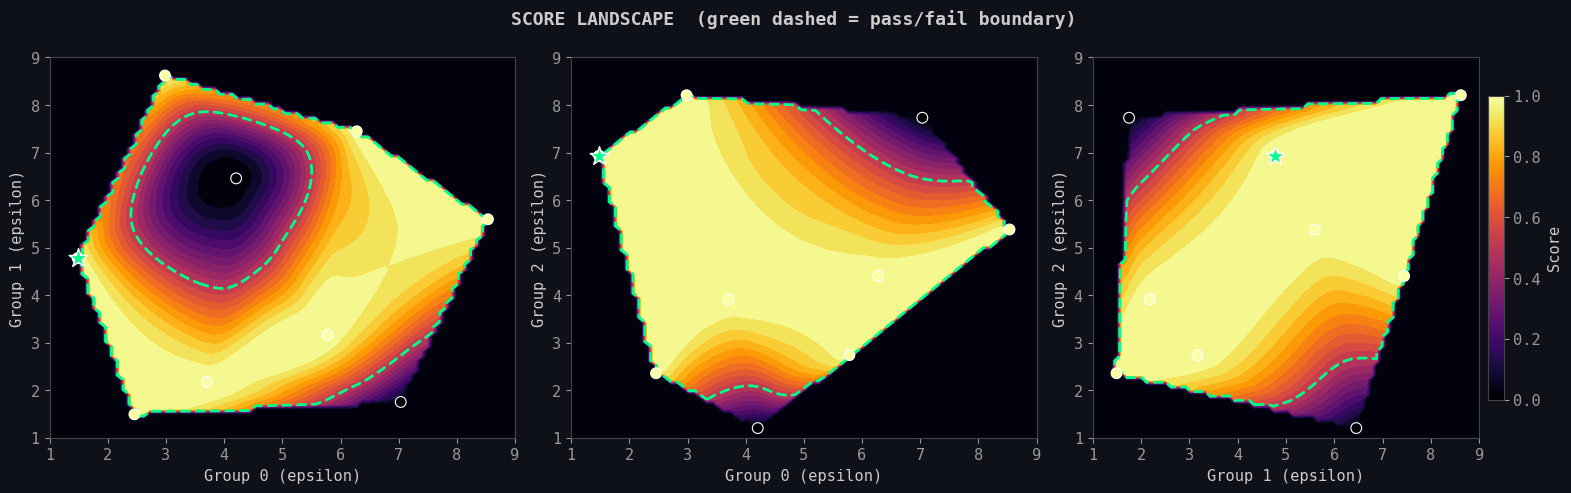

In [39]:
# 2. HEATMAPS: interpolated score landscape in epsilon space
# Shows WHERE in parameter space endocytosis happens

pairs = [(0, 1, "Group 0", "Group 1"),
         (0, 2, "Group 0", "Group 2"),
         (1, 2, "Group 1", "Group 2")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (i, j, li, lj) in zip(axes, pairs):
    xi = np.linspace(1, 9, 80)
    yi = np.linspace(1, 9, 80)
    XI, YI = np.meshgrid(xi, yi)

    if len(scores) >= 4:
        ZI = griddata(eps[:, [i, j]], scores, (XI, YI), method="cubic", fill_value=0)
        ZI = np.clip(ZI, 0, 1)
        im = ax.contourf(XI, YI, ZI, levels=20, cmap="inferno", vmin=0, vmax=1)
        ax.contour(XI, YI, ZI, levels=[0.5], colors=["#00ff88"], linewidths=2, linestyles="--")

    ax.scatter(eps[:, i], eps[:, j], c=scores, cmap="inferno",
              s=60, edgecolors="white", linewidths=0.8, vmin=0, vmax=1, zorder=5)

    # Mark the best run
    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=200,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6)

    ax.set_xlabel(f"{li} (epsilon)")
    ax.set_ylabel(f"{lj} (epsilon)")
    ax.set_xlim(1, 9)
    ax.set_ylim(1, 9)

fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1)),
             ax=axes[-1], label="Score", shrink=0.8, pad=0.02)
fig.suptitle("SCORE LANDSCAPE  (green dashed = pass/fail boundary)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

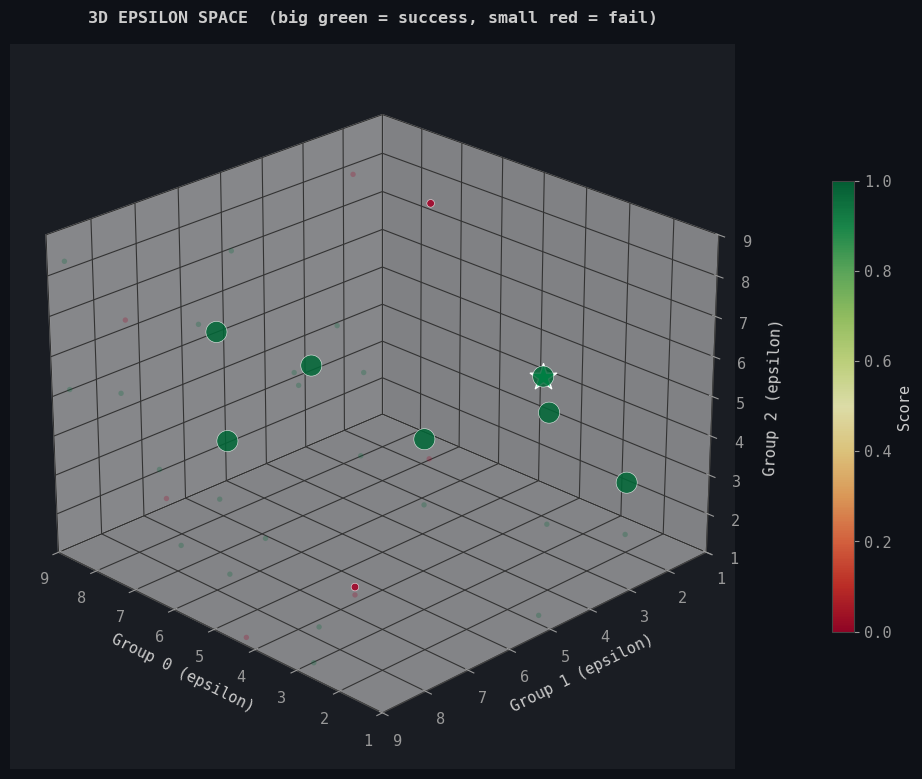

In [40]:
# 3D SCATTER: all three epsilons at once
# Size = score, color = score. One dot per run.

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#1a1d23")

# Scale dot size by score
sizes = 30 + 200 * scores

sc = ax.scatter(eps[:, 0], eps[:, 1], eps[:, 2],
                c=scores, cmap="RdYlGn", s=sizes, vmin=0, vmax=1,
                edgecolors="white", linewidths=0.4, alpha=0.85, depthshade=False)

# Star on best
best = np.argmax(scores)
ax.scatter(eps[best, 0], eps[best, 1], eps[best, 2],
           marker="*", s=400, color="#00ff88", edgecolors="white",
           linewidths=1, zorder=6, depthshade=False)

# Project shadows onto walls (shows 2D marginals)
ax.scatter(eps[:, 0], eps[:, 1], np.full(len(eps), 1),
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=1,
           edgecolors="none", depthshade=False)
ax.scatter(eps[:, 0], np.full(len(eps), 9), eps[:, 2],
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=1,
           edgecolors="none", depthshade=False)
ax.scatter(np.full(len(eps), 9), eps[:, 1], eps[:, 2],
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=1,
           edgecolors="none", depthshade=False)

ax.set_xlabel("Group 0 (epsilon)")
ax.set_ylabel("Group 1 (epsilon)")
ax.set_zlabel("Group 2 (epsilon)")
ax.set_xlim(1, 9)
ax.set_ylim(1, 9)
ax.set_zlim(1, 9)
ax.set_title("3D EPSILON SPACE  (big green = success, small red = fail)",
             fontweight="bold", fontsize=12, pad=15)
ax.view_init(elev=25, azim=135)

fig.colorbar(sc, ax=ax, label="Score", shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

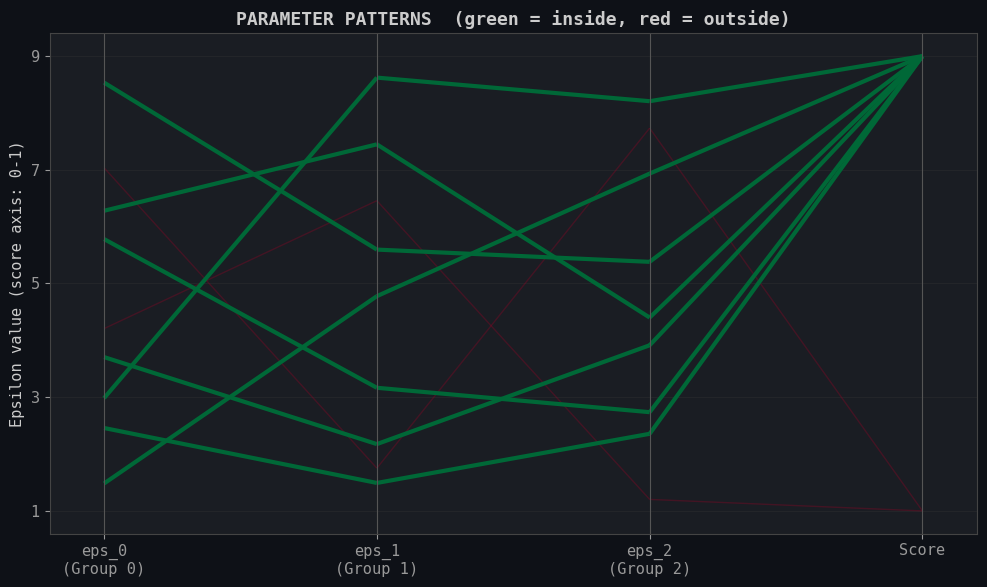

In [41]:
# PARALLEL COORDINATES
# Each line = one run, passing through eps_0, eps_1, eps_2
# Color = score. Shows which PATTERNS of epsilons work.

fig, ax = plt.subplots(figsize=(10, 6))

x_coords = [0, 1, 2, 3]  # eps_0, eps_1, eps_2, score
x_labels = ["eps_0\n(Group 0)", "eps_1\n(Group 1)", "eps_2\n(Group 2)", "Score"]

# Normalize each axis to [0, 1] for display
data = np.column_stack([eps, scores])
mins = np.array([1, 1, 1, 0], dtype=float)
maxs = np.array([9, 9, 9, 1], dtype=float)
normed = (data - mins) / (maxs - mins)

# Sort by score so high scores draw on top
order = np.argsort(scores)

for idx in order:
    y = normed[idx]
    points = np.column_stack([x_coords, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color = plt.cm.RdYlGn(scores[idx])
    alpha = 0.3 + 0.7 * scores[idx]  # failed runs more transparent
    lw = 1.0 + 2.0 * scores[idx]

    lc = LineCollection(segments, colors=[color], alpha=alpha, linewidths=lw)
    ax.add_collection(lc)

# Axis decorations
for x in x_coords:
    ax.axvline(x, color="#555", lw=0.8)

ax.set_xticks(x_coords)
ax.set_xticklabels(x_labels)
ax.set_xlim(-0.2, 3.2)
ax.set_ylim(-0.05, 1.05)

# Y-axis tick labels showing actual values
yticks = np.linspace(0, 1, 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.0f}" for v in np.linspace(1, 9, 5)])
ax.set_ylabel("Epsilon value (score axis: 0-1)")

ax.set_title("PARAMETER PATTERNS  (green = inside, red = outside)",
             fontweight="bold", fontsize=13)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

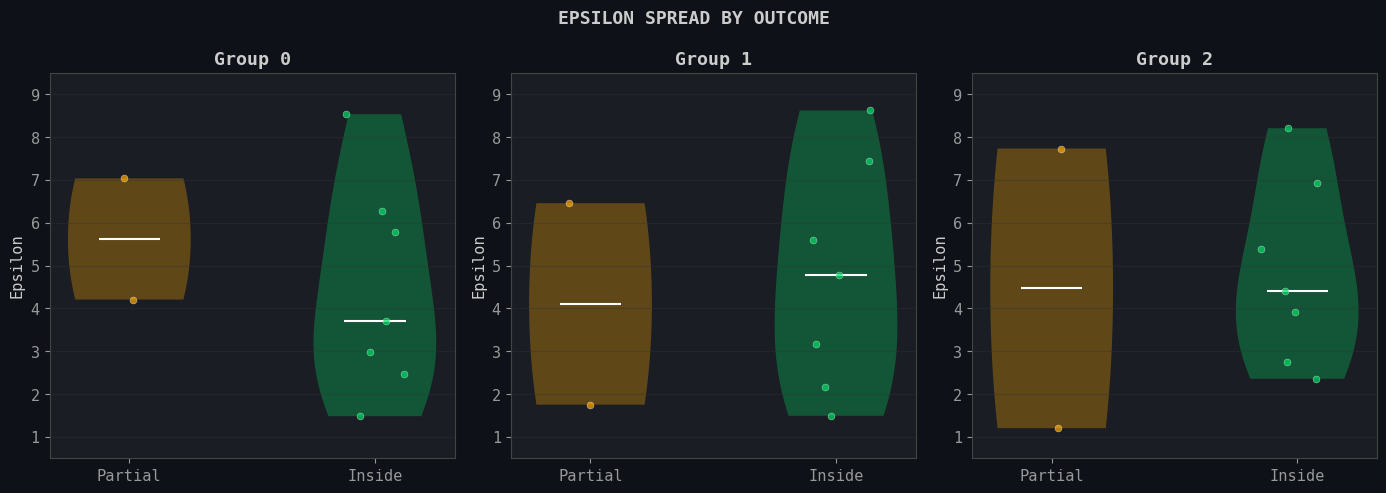

In [42]:
# 4. EPSILON SPREADS: violin + strip for inside vs outside
# Shows the DISTRIBUTION of what works vs what doesn't

inside = scores > 0.0  # any penetration at all
deep = scores > 0.5    # clearly inside

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
group_names = ["Group 0", "Group 1", "Group 2"]

for i, ax in enumerate(axes):
    categories = []
    data_cat = []

    if (~inside).sum() > 0:
        categories.append("Outside")
        data_cat.append(eps[~inside, i])
    if (inside & ~deep).sum() > 0:
        categories.append("Partial")
        data_cat.append(eps[inside & ~deep, i])
    if deep.sum() > 0:
        categories.append("Inside")
        data_cat.append(eps[deep, i])

    colors_cat = {"Outside": "#ff4444", "Partial": "#ffaa00", "Inside": "#00dd66"}
    positions = list(range(len(categories)))

    if len(data_cat) > 0:
        parts = ax.violinplot(data_cat, positions=positions, showmedians=True,
                              showextrema=False)
        for pc, cat in zip(parts["bodies"], categories):
            pc.set_facecolor(colors_cat[cat])
            pc.set_alpha(0.3)
        parts["cmedians"].set_color("white")

        # Strip plot (jittered dots)
        for pos, cat, d in zip(positions, categories, data_cat):
            jitter = np.random.normal(0, 0.06, len(d))
            ax.scatter(pos + jitter, d, c=colors_cat[cat], s=25,
                      alpha=0.7, edgecolors="white", linewidths=0.3, zorder=5)

    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Epsilon")
    ax.set_ylim(0.5, 9.5)
    ax.set_title(group_names[i], fontweight="bold")
    ax.grid(True, axis="y")

fig.suptitle("EPSILON SPREAD BY OUTCOME", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

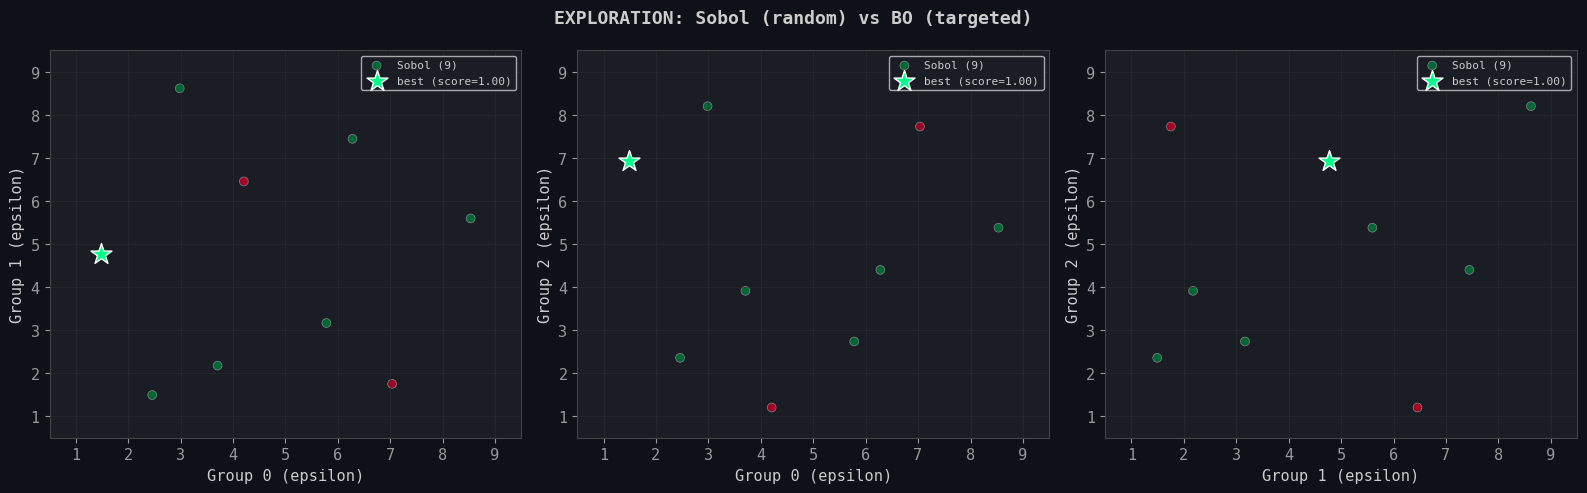

In [43]:
# 5. SAMPLING STRATEGY: where is BO choosing to explore?
# Shows Sobol (uniform) vs BO (targeted) sampling in epsilon space

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pair_idx = [(0, 1), (0, 2), (1, 2)]
pair_names = [("Group 0", "Group 1"), ("Group 0", "Group 2"), ("Group 1", "Group 2")]

sobol_mask = eval_ids < n_initial
bo_mask = eval_ids >= n_initial

for ax, (i, j), (ni, nj) in zip(axes, pair_idx, pair_names):
    # Sobol samples: circles
    if sobol_mask.sum() > 0:
        ax.scatter(eps[sobol_mask, i], eps[sobol_mask, j],
                  c=scores[sobol_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=40, marker="o", edgecolors="#888", linewidths=0.5,
                  label=f"Sobol ({sobol_mask.sum()})")

    # BO samples: diamonds, connected by trail
    if bo_mask.sum() > 1:
        bo_eps_i = eps[bo_mask, i]
        bo_eps_j = eps[bo_mask, j]
        ax.plot(bo_eps_i, bo_eps_j, color="#666", lw=0.8, alpha=0.5, zorder=3)
        ax.scatter(bo_eps_i, bo_eps_j,
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)
    elif bo_mask.sum() == 1:
        ax.scatter(eps[bo_mask, i], eps[bo_mask, j],
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)

    # Star on best
    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=250,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6,
              label=f"best (score={scores[best]:.2f})")

    ax.set_xlabel(f"{ni} (epsilon)")
    ax.set_ylabel(f"{nj} (epsilon)")
    ax.set_xlim(0.5, 9.5)
    ax.set_ylim(0.5, 9.5)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)

fig.suptitle("EXPLORATION: Sobol (random) vs BO (targeted)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

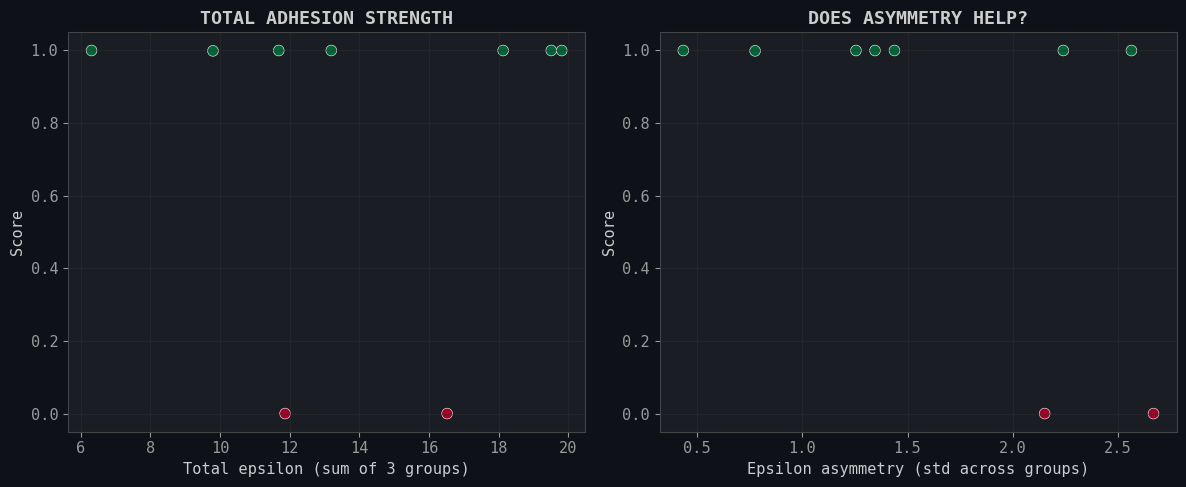

In [44]:
# 6. TOTAL EPSILON vs OUTCOME
# Is it the total adhesion strength that matters, or the pattern?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

eps_total = eps.sum(axis=1)
eps_std = eps.std(axis=1)  # asymmetry: how different are the 3 groups?

# Total epsilon vs score
sc = ax1.scatter(eps_total, scores, c=scores, cmap="RdYlGn",
                 s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax1.set_xlabel("Total epsilon (sum of 3 groups)")
ax1.set_ylabel("Score")
ax1.set_title("TOTAL ADHESION STRENGTH", fontweight="bold")
ax1.grid(True)

# Asymmetry vs score
ax2.scatter(eps_std, scores, c=scores, cmap="RdYlGn",
            s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax2.set_xlabel("Epsilon asymmetry (std across groups)")
ax2.set_ylabel("Score")
ax2.set_title("DOES ASYMMETRY HELP?", fontweight="bold")
ax2.grid(True)

plt.tight_layout()
plt.show()

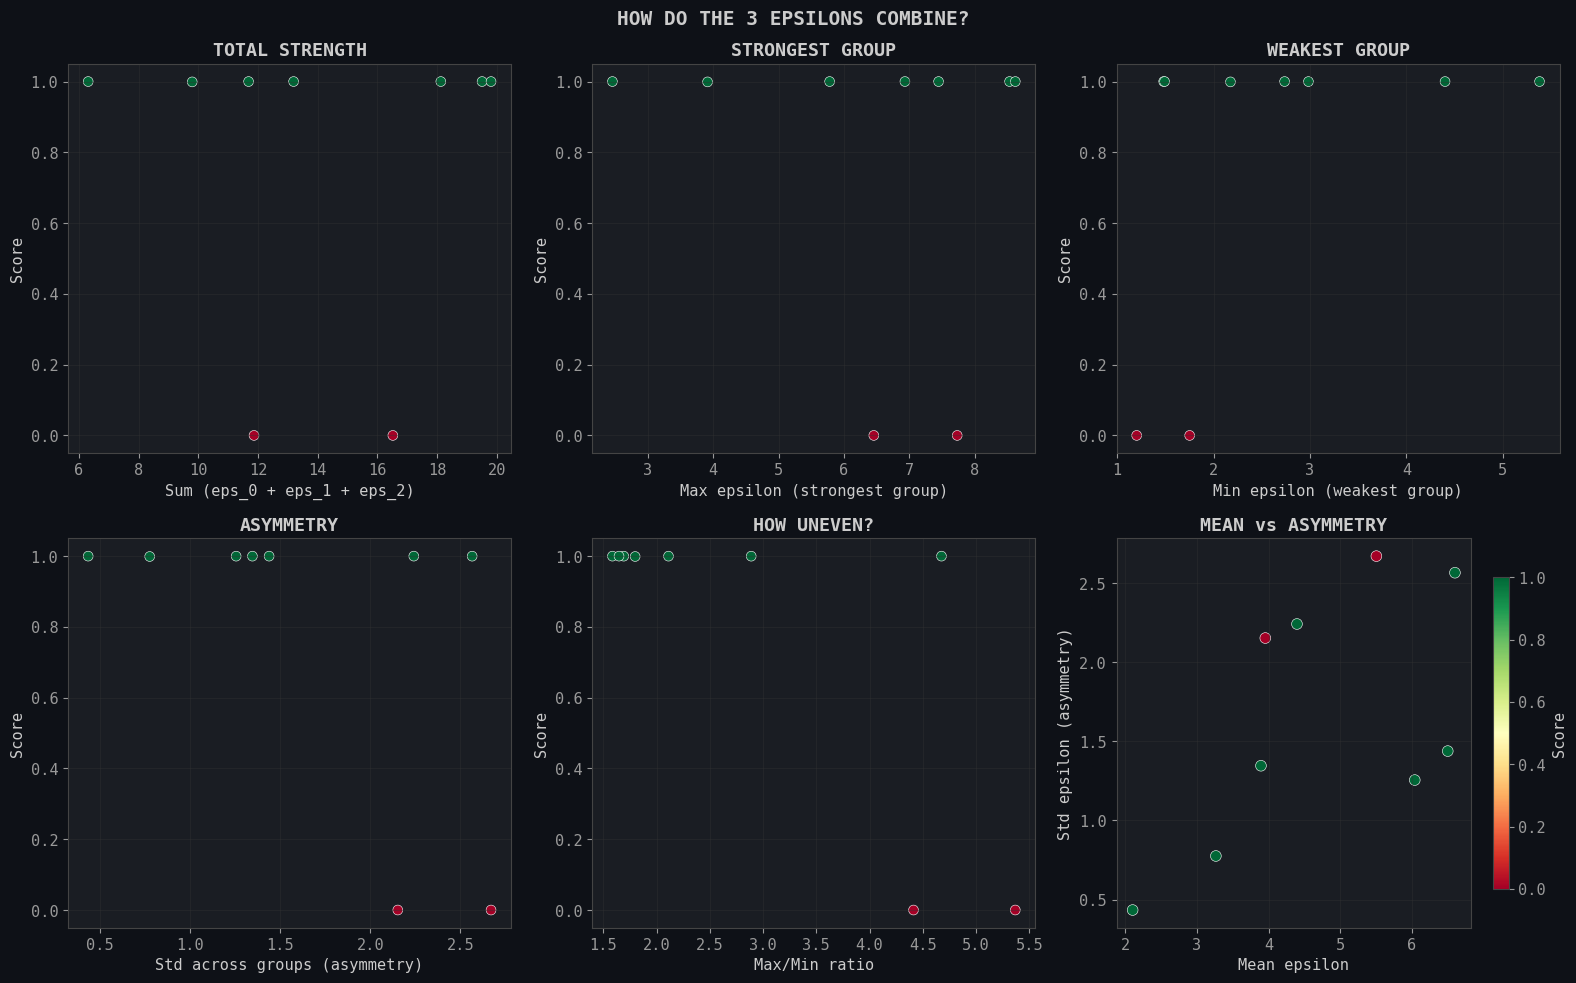

In [45]:
# COMBINED STATISTICS: how do the 3 epsilons interact?

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

eps_sum = eps.sum(axis=1)
eps_mean = eps.mean(axis=1)
eps_std = eps.std(axis=1)
eps_max = eps.max(axis=1)
eps_min = eps.min(axis=1)
eps_range = eps_max - eps_min

# --- Row 1: Derived features vs score ---

# Sum vs score
ax = axes[0, 0]
ax.scatter(eps_sum, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Sum (eps_0 + eps_1 + eps_2)")
ax.set_ylabel("Score")
ax.set_title("TOTAL STRENGTH", fontweight="bold")
ax.grid(True)

# Max epsilon vs score
ax = axes[0, 1]
ax.scatter(eps_max, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Max epsilon (strongest group)")
ax.set_ylabel("Score")
ax.set_title("STRONGEST GROUP", fontweight="bold")
ax.grid(True)

# Min epsilon vs score
ax = axes[0, 2]
ax.scatter(eps_min, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Min epsilon (weakest group)")
ax.set_ylabel("Score")
ax.set_title("WEAKEST GROUP", fontweight="bold")
ax.grid(True)

# --- Row 2: Asymmetry and ratios ---

# Asymmetry (std) vs score
ax = axes[1, 0]
ax.scatter(eps_std, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Std across groups (asymmetry)")
ax.set_ylabel("Score")
ax.set_title("ASYMMETRY", fontweight="bold")
ax.grid(True)

# Max/Min ratio vs score
ax = axes[1, 1]
ratio = eps_max / np.clip(eps_min, 0.1, None)
ax.scatter(ratio, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Max/Min ratio")
ax.set_ylabel("Score")
ax.set_title("HOW UNEVEN?", fontweight="bold")
ax.grid(True)

# Mean vs Std (colored by score) - shows the full picture
ax = axes[1, 2]
sc = ax.scatter(eps_mean, eps_std, c=scores, cmap="RdYlGn", s=60,
                edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel("Mean epsilon")
ax.set_ylabel("Std epsilon (asymmetry)")
ax.set_title("MEAN vs ASYMMETRY", fontweight="bold")
ax.grid(True)
fig.colorbar(sc, ax=ax, label="Score", shrink=0.8)

fig.suptitle("HOW DO THE 3 EPSILONS COMBINE?", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()